In [1]:
from models.Arima import MyArima
from models.LSTM import MyLSTM
from models.GRU import MyGRU
from models.Prophet import MyProphet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
df = yf.download('BTC-USD', start='2019-01-01', end='2021-12-31')
test_data = yf.download('BTC-USD', start='2022-01-01', end='2022-04-01')
data = df[['Close']].values
actual_prices = test_data[['Close']].values
length = len(actual_prices)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


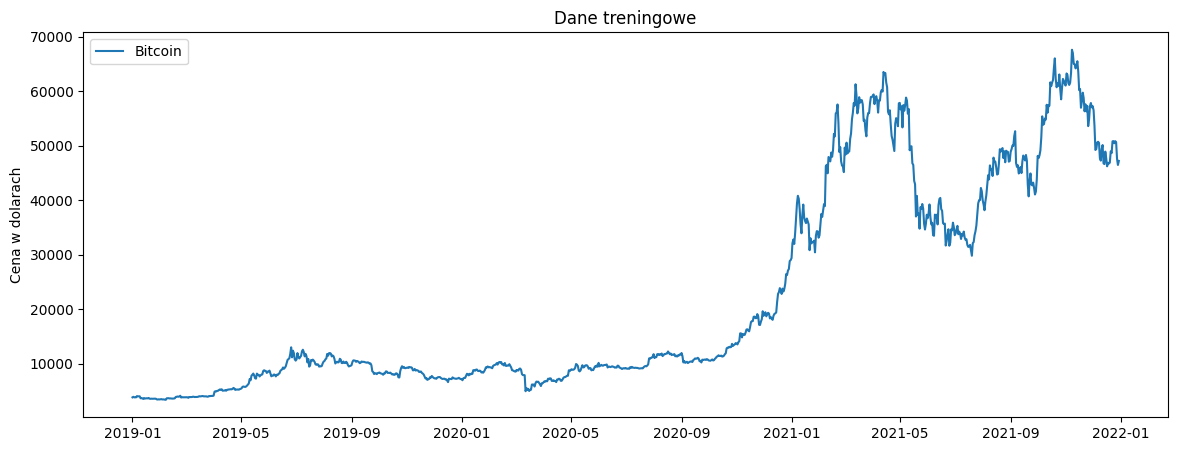

In [3]:
plt.figure(figsize=(14,5))
plt.plot(df.index, data, label="Bitcoin")
plt.title("Dane treningowe")
plt.ylabel('Cena w dolarach')
plt.legend()
plt.show()

In [4]:
gru_model = MyGRU(epochs=5, look_back=10)
gru_model.create_model()
gru_model.fit(data)

lstm_model = MyLSTM(epochs=5, look_back=10)
lstm_model.create_model()
lstm_model.fit(data)

Epoch 1/5


C:\Users\Michał\Desktop\crypto\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0095 - val_loss: 0.0498
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0010 - val_loss: 0.0025
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3.6262e-04 - val_loss: 0.0042
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.2312e-04 - val_loss: 0.0023
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.3248e-04 - val_loss: 0.0023
Epoch 1/5


C:\Users\Michał\Desktop\crypto\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0131 - val_loss: 0.0089
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.0757e-04 - val_loss: 0.0048
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.3051e-04 - val_loss: 0.0076
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.6852e-04 - val_loss: 0.0044
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.4955e-04 - val_loss: 0.0060


In [5]:
total_dataset = np.concatenate((data, actual_prices), axis=0)
predicted_prices_gru = gru_model.predict(total_dataset, length)
predicted_prices_lstm = lstm_model.predict(total_dataset, length)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step


In [6]:
start_date = datetime.strptime('2022-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2022-04-01', '%Y-%m-%d')
periods = (end_date - start_date).days

prophet_model = MyProphet()
prophet_model.create_model()
prophet_model.fit(df)
predictions = prophet_model.predict(periods)

11:01:03 - cmdstanpy - INFO - Chain [1] start processing
11:01:05 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
arima_model = MyArima(interval=90)
arima_model.fit(df)
forecast_dates = pd.date_range(start='2022-01-01', end='2022-03-31')
forecast_length = len(forecast_dates)
arima_predictions = arima_model.predict(forecast_length, forecast_dates)

C:\Users\Michał\Desktop\crypto\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


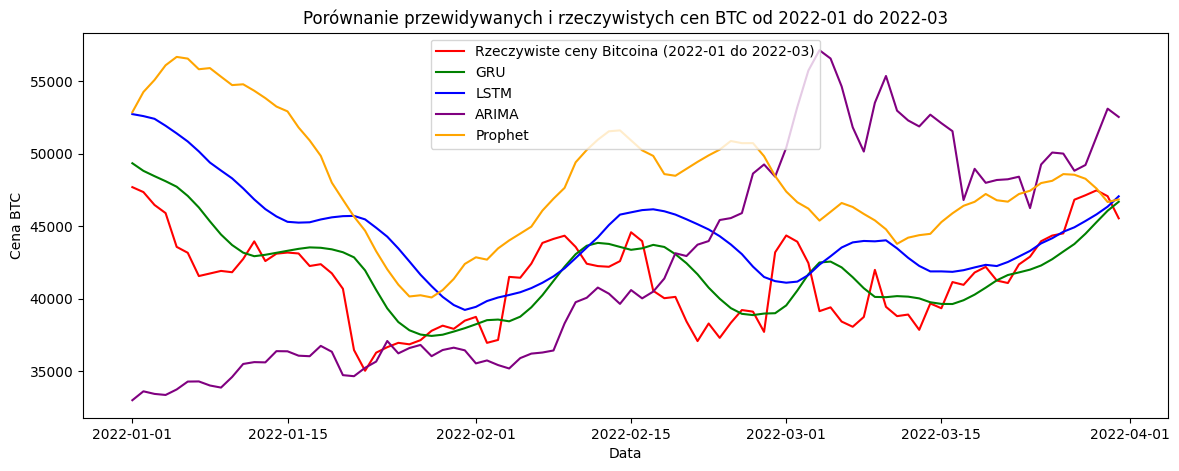

In [8]:
plt.figure(figsize=(14,5))
plt.plot(test_data.index,test_data["Close"], color='red', label='Rzeczywiste ceny Bitcoina (2022-01 do 2022-03)')
plt.plot(test_data.index,predicted_prices_gru, color='green', label='GRU')
plt.plot(test_data.index,predicted_prices_lstm, color='blue', label='LSTM')
plt.plot(arima_predictions, color='purple', label='ARIMA')
plt.plot(test_data.index,predictions['yhat'], label='Prophet', color='orange')
plt.title('Porównanie przewidywanych i rzeczywistych cen BTC od 2022-01 do 2022-03')
plt.xlabel('Data')
plt.ylabel('Cena BTC')
plt.legend()
plt.show()

In [9]:
test_data_0 = test_data["Close"].iloc[0][0]
arima_predictions_0 = arima_predictions.iloc[0][0]
bias = arima_predictions_0 - test_data_0
for i in range(len(arima_predictions)):
    arima_predictions.iloc[i] = int(arima_predictions.iloc[i]) - bias


prophet_predictions_0 = float(predictions['yhat'].iloc[0])
bias = prophet_predictions_0 - test_data_0
for i in range(len(predictions)):
    predictions['yhat'].iloc[i] = float(predictions['yhat'].iloc[i]) - bias

C:\Users\Michał\AppData\Local\Temp\ipykernel_16392\1087585817.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_data_0 = test_data["Close"].iloc[0][0]
C:\Users\Michał\AppData\Local\Temp\ipykernel_16392\1087585817.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  arima_predictions_0 = arima_predictions.iloc[0][0]
C:\Users\Michał\AppData\Local\Temp\ipykernel_16392\1087585817.py:5: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  arima_predictions.iloc[i] = int(arima_predictions.iloc[i]) - bias
C:\Users\Michał\AppData\Lo

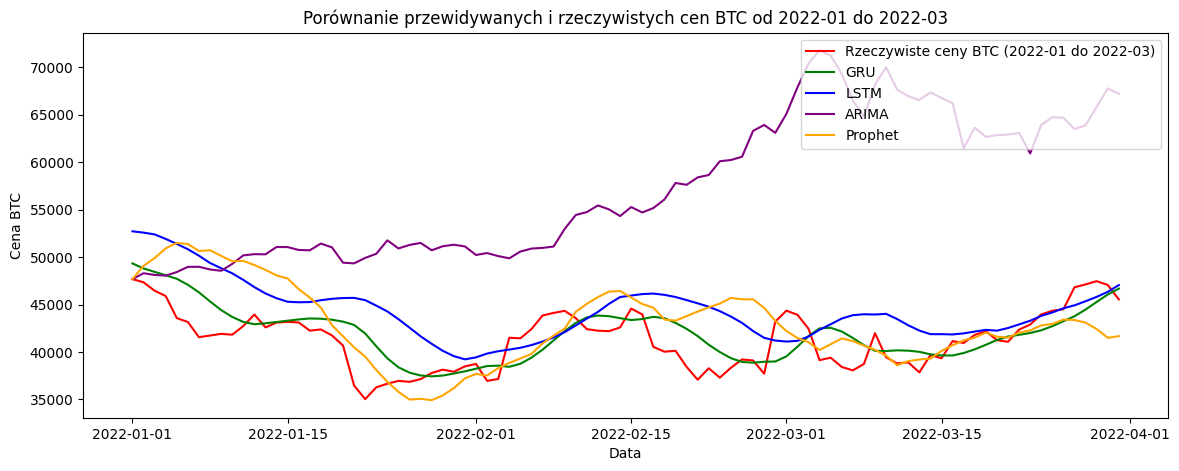

In [10]:
plt.figure(figsize=(14,5))
plt.plot(test_data.index,test_data["Close"], color='red', label='Rzeczywiste ceny BTC (2022-01 do 2022-03)')
plt.plot(test_data.index,predicted_prices_gru, color='green', label='GRU')
plt.plot(test_data.index,predicted_prices_lstm, color='blue', label='LSTM')
plt.plot(arima_predictions, color='purple', label='ARIMA')
plt.plot(test_data.index,predictions['yhat'], label='Prophet', color='orange')
plt.title('Porównanie przewidywanych i rzeczywistych cen BTC od 2022-01 do 2022-03')
plt.xlabel('Data')
plt.ylabel('Cena BTC')
plt.legend(loc='upper right')
plt.show()

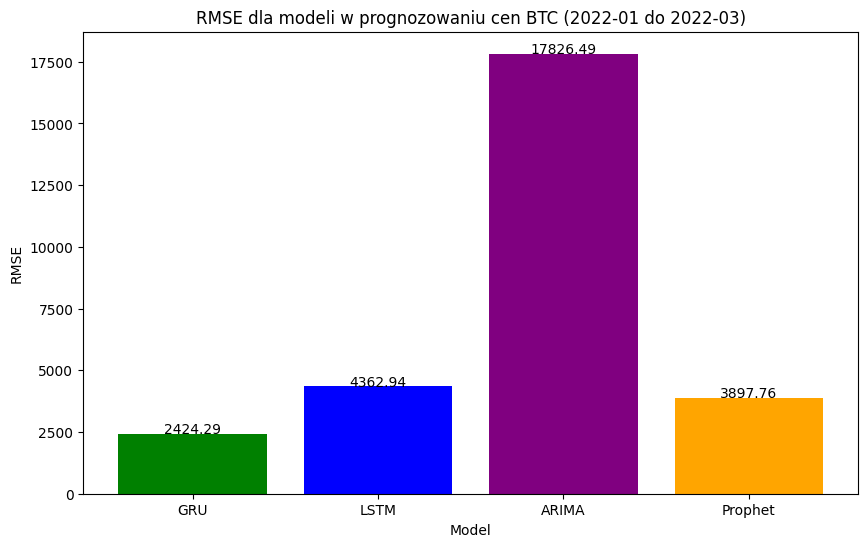

In [11]:
from sklearn.metrics import mean_squared_error

rmse_gru = np.sqrt(mean_squared_error(test_data["Close"], predicted_prices_gru))
rmse_lstm = np.sqrt(mean_squared_error(test_data["Close"], predicted_prices_lstm))
rmse_arima = np.sqrt(mean_squared_error(test_data["Close"], arima_predictions))
rmse_prophet = np.sqrt(mean_squared_error(test_data["Close"], predictions['yhat']))

# Przygotowanie danych do wykresu
model_names = ['GRU', 'LSTM', 'ARIMA', 'Prophet']
rmse_values = [rmse_gru, rmse_lstm, rmse_arima, rmse_prophet]

# Tworzenie wykresu kolumnowego
plt.figure(figsize=(10, 6))
plt.bar(model_names, rmse_values, color=['green', 'blue', 'purple', 'orange'])
plt.title('RMSE dla modeli w prognozowaniu cen BTC (2022-01 do 2022-03)')
plt.xlabel('Model')
plt.ylabel('RMSE')

# Dodanie wartości RMSE nad słupkami
for i, value in enumerate(rmse_values):
    plt.text(i, value + 0.01, f'{value:.2f}', ha='center', fontsize=10)

plt.show()
